In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, classification_report
from scipy.stats import randint, uniform
import time

In [2]:
data = pd.read_csv('/Users/nheechan/Desktop/DS capstone/water-quality-england/data/England_dataset.csv')
data.head()

,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,23.40,152.00,10.2,3.900,7.78,11.46,0.20,4.5,42.847368,Poor
1,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,21.30,102.00,10.2,3.430,7.78,8.30,0.20,4.5,43.496934,Poor
2,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,4.03,12.50,10.2,0.495,7.78,8.90,3.83,4.5,60.444542,Marginal
3,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,5.09,4.18,10.2,0.780,7.78,8.30,2.11,4.5,59.285522,Marginal
4,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,5.10,3.58,10.2,0.728,7.78,8.20,1.46,4.5,59.820608,Marginal


In [3]:
data2 = data.drop(columns=['Country', 'Area', 'Waterbody Type', 'Date', 'CCME_Values'])
data2.head()

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_WQI
0,23.40,152.00,10.2,3.900,7.78,11.46,0.20,4.5,Poor
1,21.30,102.00,10.2,3.430,7.78,8.30,0.20,4.5,Poor
2,4.03,12.50,10.2,0.495,7.78,8.90,3.83,4.5,Marginal
3,5.09,4.18,10.2,0.780,7.78,8.30,2.11,4.5,Marginal
4,5.10,3.58,10.2,0.728,7.78,8.20,1.46,4.5,Marginal


In [4]:
X = data2.drop(columns=['CCME_WQI'])
y = data2['CCME_WQI']

print(X.shape)
print(y.shape)

(2129198, 8)
(2129198,)


In [5]:
## 60% for training, 20% for validation, and 20% for testing
## Hold out 20% for testing
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Split the remaining 80% into training and validation sets (60% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Validation set size: {X_val.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 1277518 samples
Validation set size: 425840 samples
Test set size: 425840 samples


In [6]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Random Forest

### Baseline model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf_base_classifier = RandomForestClassifier(random_state=42)
rf_base_classifier.fit(X_train_scaled, y_train)
y_pred_rf_base = rf_base_classifier.predict(X_val_scaled)

In [17]:
rf_base_accuracy = accuracy_score(y_val, y_pred_rf_base)
print(f'Random Forest Classifier Accuracy: {rf_base_accuracy:.4f}')
rf_base_cfmatrix = confusion_matrix(y_val, y_pred_rf_base)
rf_base_precision = precision_score(y_val, y_pred_rf_base, average='weighted')
rf_base_recall = recall_score(y_val, y_pred_rf_base, average='weighted')
print(f'Precision: {rf_base_precision:.4f}')
print(f'Recall: {rf_base_recall:.4f}')

Random Forest Classifier Accuracy: 0.9972
Precision: 0.9972
Recall: 0.9972


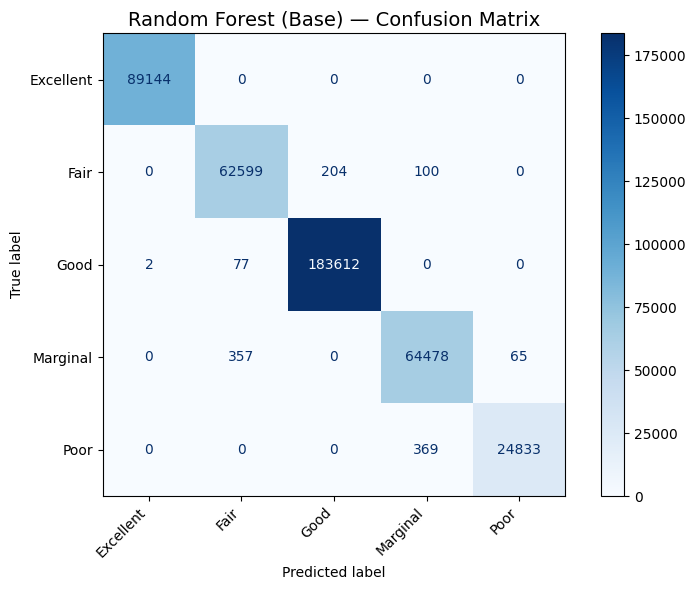

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_base_cfmatrix,
    display_labels=rf_base_classifier.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Random Forest (Base) — Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### RandomizedSearchCV

In [15]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Subsample — same reason as regression, RF is slow at 1.27M rows
SEARCH_SAMPLE = 200_000
idx_rf = np.random.default_rng(42).choice(len(X_train_scaled), size=SEARCH_SAMPLE, replace=False)
X_rf_search = X_train_scaled[idx_rf]
y_rf_search = y_train.iloc[idx_rf].reset_index(drop=True)

rf_clf_params = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    # class_weight handles the Good(183K) vs Poor(25K) imbalance
    'class_weight': ['balanced', 'balanced_subsample', None],
}

rf_clf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_clf_params,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',   # weighted F1 across all 5 classes
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

start = time.time()
rf_clf_search.fit(X_rf_search, y_rf_search)
print(f"RF classifier search time: {time.time() - start:.1f}s")
print("Best params:", rf_clf_search.best_params_)
print(f"Best CV F1: {rf_clf_search.best_score_:.4f}")

y_val_pred_rf_clf = rf_clf_search.best_estimator_.predict(X_val_scaled)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


python(39450) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39451) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39452) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39453) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39454) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39455) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39456) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(39457) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END class_weight=None, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=153; total time=  32.5s
[CV] END class_weight=None, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=153; total time=  32.5s
[CV] END class_weight=None, max_depth=20, max_features=0.3, min_samples_leaf=8, min_samples_split=5, n_estimators=153; total time=  32.8s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=13, n_estimators=207; total time=  33.5s
[CV] END class_weight=None, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=13, n_estimators=207; total time=  33.6s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=171; total time=  33.8s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=171; total time=  33.8s
[CV] END class_weight=None, 

In [16]:
print(f"\nVal Accuracy: {accuracy_score(y_val, y_val_pred_rf_clf):.4f}")
print(classification_report(y_val, y_val_pred_rf_clf,
      target_names=['Excellent','Fair','Good','Marginal','Poor']))


Val Accuracy: 0.9969
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00     89144
        Fair       0.99      0.99      0.99     62903
        Good       1.00      1.00      1.00    183691
    Marginal       0.99      0.99      0.99     64900
        Poor       0.99      0.99      0.99     25202

    accuracy                           1.00    425840
   macro avg       1.00      0.99      1.00    425840
weighted avg       1.00      1.00      1.00    425840



## XGBoost

### Baseline model

In [17]:
import xgboost as xgb
from xgboost import XGBClassifier

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [19]:
dict(enumerate(le.classes_))

{0: 'Excellent', 1: 'Fair', 2: 'Good', 3: 'Marginal', 4: 'Poor'}

In [15]:
xgb_base_classifier = XGBClassifier(
    n_estimators=100, # number of boosting rounds (trees to build)
    learning_rate = 0.05, # forces the model to learn slowly; lower learning rate = more robust but needs more trees to compensate
    max_depth = 6,
    subsample = 0.8, # fraction of training rows randomly sampled to build each tree
    colsample_bytree = 0.8,
    objective='multi:softprob', # return softmax probability distribution
    tree_method='hist', # use histogram-based algorithm for faster training on large datasets
    random_state=42,
    n_jobs=-1
)

xgb_base_classifier.fit(
    X_train_scaled, y_train_enc,
    eval_set=[(X_val_scaled, y_val_enc)],
    verbose=25   # prints every 25 rounds so you can see progress
)
y_pred_xgb_base = xgb_base_classifier.predict(X_val_scaled)

[0]	validation_0-mlogloss:1.33245
[25]	validation_0-mlogloss:0.43346
[50]	validation_0-mlogloss:0.19434
[75]	validation_0-mlogloss:0.10519
[99]	validation_0-mlogloss:0.06901


The loss is still decreasing at around the last round (round 99), which means my model hasn't fully converged yet. Could get better performance by increasing n_estimators (e.g. to 300–500) and adding early_stopping_rounds=20 so XGBoost stops automatically when validation loss stops improving

In [16]:
xgb_base_accuracy = accuracy_score(y_val_enc, y_pred_xgb_base)
print(f'XGBoost Classifier Accuracy: {xgb_base_accuracy:.4f}')
xgb_base_cfmatrix = confusion_matrix(y_val_enc, y_pred_xgb_base)
xgb_base_precision = precision_score(y_val_enc, y_pred_xgb_base, average='weighted')
xgb_base_recall = recall_score(y_val_enc, y_pred_xgb_base, average='weighted')
print(f'Precision: {xgb_base_precision:.4f}')
print(f'Recall: {xgb_base_recall:.4f}')

XGBoost Classifier Accuracy: 0.9855
Precision: 0.9855
Recall: 0.9855


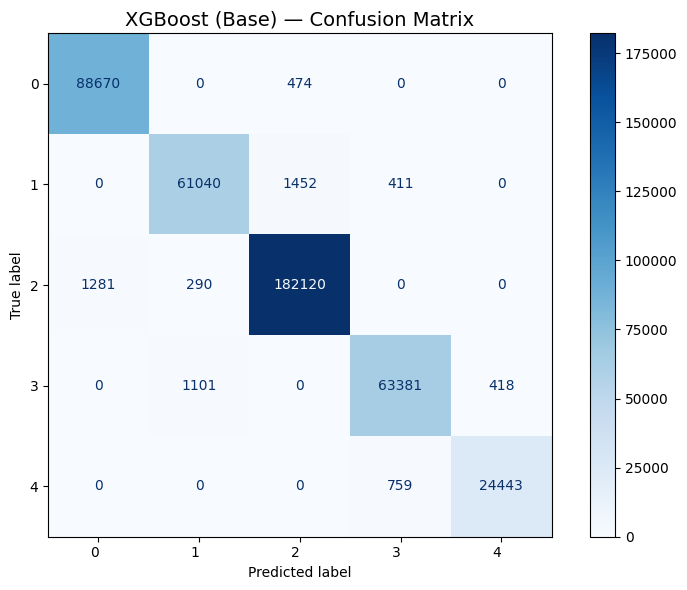

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_base_cfmatrix,
    display_labels=xgb_base_classifier.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('XGBoost (Base) — Confusion Matrix', fontsize=14)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

### Randomized Search CV

In [22]:
from xgboost import XGBClassifier
from scipy.stats import uniform

xgb_clf_params = {
    'n_estimators': randint(200, 600),   # baseline loss still dropping at 99 — search higher
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2),
}

xgb_clf_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    param_distributions=xgb_clf_params,
    n_iter=30,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

start = time.time()
xgb_clf_search.fit(X_train_scaled, y_train_enc)   # XGBoost needs encoded labels
print(f"XGB classifier search time: {time.time() - start:.1f}s")
print("Best params:", xgb_clf_search.best_params_)
print(f"Best CV F1: {xgb_clf_search.best_score_:.4f}")

y_val_pred_xgb_clf = le.inverse_transform(              # decode back to class names
    xgb_clf_search.best_estimator_.predict(X_val_scaled)
)
print(f"\nVal Accuracy: {accuracy_score(y_val, y_val_pred_xgb_clf):.4f}")
print(classification_report(y_val, y_val_pred_xgb_clf,
      target_names=['Excellent','Fair','Good','Marginal','Poor']))


Fitting 3 folds for each of 30 candidates, totalling 90 fits


python(41096) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41097) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41098) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41099) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41100) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41101) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41102) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(41103) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=5, min_child_weight=8, n_estimators=388, reg_alpha=0.596850157946487, reg_lambda=1.3916655057071823, subsample=0.6399899663272012; total time= 3.3min
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=5, min_child_weight=8, n_estimators=388, reg_alpha=0.596850157946487, reg_lambda=1.3916655057071823, subsample=0.6399899663272012; total time= 3.3min
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.28570714885887566, max_depth=5, min_child_weight=8, n_estimators=388, reg_alpha=0.596850157946487, reg_lambda=1.3916655057071823, subsample=0.6399899663272012; total time= 3.3min
[CV] END colsample_bytree=0.6727299868828402, learning_rate=0.06318730785749581, max_depth=6, min_child_weight=6, n_estimators=452, reg_alpha=0.43194501864211576, reg_lambda=1.0824582803960838, subsample=0.8447411578889518; total time= 3.9min
[CV] END colsample_bytree=0.672729986

## LightGBM

### Baseline

In [7]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

In [8]:
lgb_base_classifier = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multiclass',
    random_state=42,
    n_jobs=-1
)
lgb_base_classifier.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1277518, number of used features: 8
[LightGBM] [Info] Start training from score -1.565343
[LightGBM] [Info] Start training from score -1.917398
[LightGBM] [Info] Start training from score -0.839309
[LightGBM] [Info] Start training from score -1.875499
[LightGBM] [Info] Start training from score -2.835186


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
y_pred_lgb_base = lgb_base_classifier.predict(X_val_scaled)
lgb_base_accuracy = accuracy_score(y_val, y_pred_lgb_base)
print(f'LightGBM Classifier Accuracy: {lgb_base_accuracy:.4f}')
lgb_base_cfmatrix = confusion_matrix(y_val, y_pred_lgb_base)
lgb_base_precision = precision_score(y_val, y_pred_lgb_base, average='weighted')
lgb_base_recall = recall_score(y_val, y_pred_lgb_base, average='weighted')
print(f'Precision: {lgb_base_precision:.4f}')
print(f'Recall: {lgb_base_recall:.4f}')

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classifier Accuracy: 0.9966
Precision: 0.9966
Recall: 0.9966


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_lgb_base, 
      target_names=['Excellent','Fair','Good','Marginal','Poor']))

              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00     89144
        Fair       0.99      0.99      0.99     62903
        Good       1.00      1.00      1.00    183691
    Marginal       0.99      0.99      0.99     64900
        Poor       0.99      0.99      0.99     25202

    accuracy                           1.00    425840
   macro avg       1.00      0.99      0.99    425840
weighted avg       1.00      1.00      1.00    425840



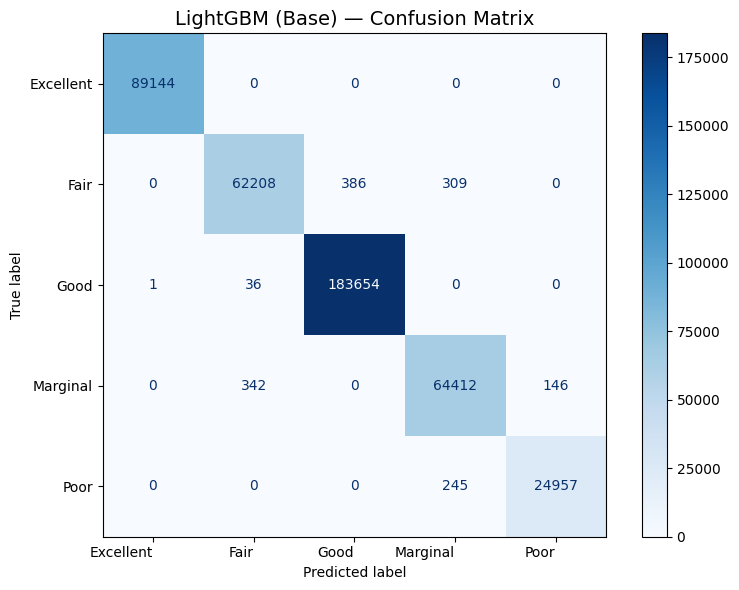

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=lgb_base_cfmatrix,
    display_labels=lgb_base_classifier.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('LightGBM (Base) — Confusion Matrix', fontsize=14)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

### Randomized Search CV

In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf_params = {
    'n_estimators': randint(100, 500),
    'num_leaves': randint(20, 150),
    'learning_rate': uniform(0.01, 0.29),
    'max_depth': randint(3, 12),
    'min_child_samples': randint(10, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2),
    'class_weight': ['balanced', None],
}

lgbm_clf_search = RandomizedSearchCV(
    LGBMClassifier(
        objective='multiclass',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    param_distributions=lgbm_clf_params,
    n_iter=30,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

start = time.time()
lgbm_clf_search.fit(X_train_scaled, y_train)   # LightGBM handles string labels natively
print(f"LGBM classifier search time: {time.time() - start:.1f}s")
print("Best params:", lgbm_clf_search.best_params_)
print(f"Best CV F1: {lgbm_clf_search.best_score_:.4f}")

y_val_pred_lgbm_clf = lgbm_clf_search.best_estimator_.predict(X_val_scaled)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

[CV] END class_weight=balanced, colsample_bytree=0.8469926038510867, learning_rate=0.18737941654160145, max_depth=11, min_child_samples=58, n_estimators=158, num_leaves=34, reg_alpha=0.45606998421703593, reg_lambda=1.5703519227860272, subsample=0.6798695128633439; total time= 1.3min
[CV] END class_weight=balanced, colsample_bytree=0.8469926038510867, learning_rate=0.18737941654160145, max_depth=11, min_child_samples=58, n_estimators=158, num_leaves=34, reg_alpha=0.45606998421703593, reg_lambda=1.5703519227860272, subsample=0.6798695128633439; total time= 1.3min
[CV] END class_weight=balanced, colsample_bytree=0.9186171947440931, learning_rate=0.0631960890611875, max_depth=10, min_child_samples=70, n_estimators=120, num_leaves=122, reg_alpha=0.44583275285359114, reg_lambda=0.19994983163600577, subsample=0.7836995567863468; total time= 1.5min
[CV] END class_weight=balanced, colsample_bytree=0.9186171947440931, learning_rate=0.0631960890611875, max_depth=10, min_child_samples=70, n_estima

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.8469926038510867, learning_rate=0.18737941654160145, max_depth=11, min_child_samples=58, n_estimators=158, num_leaves=34, reg_alpha=0.45606998421703593, reg_lambda=1.5703519227860272, subsample=0.6798695128633439; total time= 1.4min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.9932923543227152, learning_rate=0.14536123904191417, max_depth=7, min_child_samples=60, n_estimators=234, num_leaves=40, reg_alpha=0.450499251969543, reg_lambda=0.026529922319733057, subsample=0.9768807022739411; total time= 2.0min
[CV] END class_weight=balanced, colsample_bytree=0.9932923543227152, learning_rate=0.14536123904191417, max_depth=7, min_child_samples=60, n_estimators=234, num_leaves=40, reg_alpha=0.450499251969543, reg_lambda=0.026529922319733057, subsample=0.9768807022739411; total time= 2.1min
[CV] END class_weight=balanced, colsample_bytree=0.9932923543227152, learning_rate=0.14536123904191417, max_depth=7, min_child_samples=60, n_estimators=234, num_leaves=40, reg_alpha=0.450499251969543, reg_lambda=0.026529922319733057, subsample=0.9768807022739411; total time= 2.2min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.8404460046972835, learning_rate=0.21534104756085318, max_depth=8, min_child_samples=62, n_estimators=357, num_leaves=107, reg_alpha=0.8324426408004217, reg_lambda=0.4246782213565523, subsample=0.6727299868828402; total time= 4.3min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.6693458614031088, learning_rate=0.12340757619623982, max_depth=4, min_child_samples=13, n_estimators=101, num_leaves=73, reg_alpha=0.5467102793432796, reg_lambda=0.3697089110510541, subsample=0.9878338511058234; total time=  41.7s
[CV] END class_weight=balanced, colsample_bytree=0.8404460046972835, learning_rate=0.21534104756085318, max_depth=8, min_child_samples=62, n_estimators=357, num_leaves=107, reg_alpha=0.8324426408004217, reg_lambda=0.4246782213565523, subsample=0.6727299868828402; total time= 4.4min
[CV] END class_weight=balanced, colsample_bytree=0.8404460046972835, learning_rate=0.21534104756085318, max_depth=8, min_child_samples=62, n_estimators=357, num_leaves=107, reg_alpha=0.8324426408004217, reg_lambda=0.4246782213565523, subsample=0.6727299868828402; total time= 4.4min
[CV] END class_weight=balanced, colsample_bytree=0.6693458614031088, learning_rate=0.12340757619623982, max_depth=4, min_child_samples=13, n_estimators=

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.6693458614031088, learning_rate=0.12340757619623982, max_depth=4, min_child_samples=13, n_estimators=101, num_leaves=73, reg_alpha=0.5467102793432796, reg_lambda=0.3697089110510541, subsample=0.9878338511058234; total time=  38.0s
[CV] END class_weight=None, colsample_bytree=0.9233589392465844, learning_rate=0.09833799306027749, max_depth=7, min_child_samples=11, n_estimators=439, num_leaves=111, reg_alpha=0.4401524937396013, reg_lambda=0.24407646968955765, subsample=0.798070764044508; total time= 4.0min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7301321323053057, learning_rate=0.12271641400994977, max_depth=4, min_child_samples=62, n_estimators=379, num_leaves=143, reg_alpha=0.27599918202254337, reg_lambda=0.5925470114081648, subsample=0.6661067756252009; total time= 1.8min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

[CV] END class_weight=None, colsample_bytree=0.7301321323053057, learning_rate=0.12271641400994977, max_depth=4, min_child_samples=62, n_estimators=379, num_leaves=143, reg_alpha=0.27599918202254337, reg_lambda=0.5925470114081648, subsample=0.6661067756252009; total time= 2.2min
[CV] END class_weight=None, colsample_bytree=0.9233589392465844, learning_rate=0.09833799306027749, max_depth=7, min_child_samples=11, n_estimators=439, num_leaves=111, reg_alpha=0.4401524937396013, reg_lambda=0.24407646968955765, subsample=0.798070764044508; total time= 4.6min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7301321323053057, learning_rate=0.12271641400994977, max_depth=4, min_child_samples=62, n_estimators=379, num_leaves=143, reg_alpha=0.27599918202254337, reg_lambda=0.5925470114081648, subsample=0.6661067756252009; total time= 2.4min
[CV] END class_weight=balanced, colsample_bytree=0.9947547746402069, learning_rate=0.23395098309603066, max_depth=10, min_child_samples=97, n_estimators=162, num_leaves=100, reg_alpha=0.71134195274865, reg_lambda=1.5803510810624113, subsample=0.8423839899124046; total time= 2.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7799016533479063, learning_rate=0.12459356844052617, max_depth=6, min_child_samples=23, n_estimators=450, num_leaves=67, reg_alpha=0.3265407688058354, reg_lambda=1.1408879488107988, subsample=0.8083337040103294; total time= 4.7min
[CV] END class_weight=None, colsample_bytree=0.7799016533479063, learning_rate=0.12459356844052617, max_depth=6, min_child_samples=23, n_estimators=450, num_leaves=67, reg_alpha=0.3265407688058354, reg_lambda=1.1408879488107988, subsample=0.8083337040103294; total time= 4.8min
[CV] END class_weight=None, colsample_bytree=0.7799016533479063, learning_rate=0.12459356844052617, max_depth=6, min_child_samples=23, n_estimators=450, num_leaves=67, reg_alpha=0.3265407688058354, reg_lambda=1.1408879488107988, subsample=0.8083337040103294; total time= 4.8min
[CV] END class_weight=None, colsample_bytree=0.9233589392465844, learning_rate=0.09833799306027749, max_depth=7, min_child_samples=11, n_estimators=439, num_leaves=11

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.9083868719818244, learning_rate=0.1532007229456733, max_depth=11, min_child_samples=88, n_estimators=114, num_leaves=109, reg_alpha=0.02541912674409519, reg_lambda=0.2157828539866089, subsample=0.6125716742746937; total time= 1.7min
[CV] END class_weight=balanced, colsample_bytree=0.9083868719818244, learning_rate=0.1532007229456733, max_depth=11, min_child_samples=88, n_estimators=114, num_leaves=109, reg_alpha=0.02541912674409519, reg_lambda=0.2157828539866089, subsample=0.6125716742746937; total time= 1.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7433862914177091, learning_rate=0.04360202726228762, max_depth=9, min_child_samples=82, n_estimators=427, num_leaves=31, reg_alpha=0.3308980248526492, reg_lambda=0.12711670057204727, subsample=0.7243929286862649; total time= 3.6min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7433862914177091, learning_rate=0.04360202726228762, max_depth=9, min_child_samples=82, n_estimators=427, num_leaves=31, reg_alpha=0.3308980248526492, reg_lambda=0.12711670057204727, subsample=0.7243929286862649; total time= 3.9min
[CV] END class_weight=None, colsample_bytree=0.7433862914177091, learning_rate=0.04360202726228762, max_depth=9, min_child_samples=82, n_estimators=427, num_leaves=31, reg_alpha=0.3308980248526492, reg_lambda=0.12711670057204727, subsample=0.7243929286862649; total time= 4.0min
[CV] END class_weight=balanced, colsample_bytree=0.9083868719818244, learning_rate=0.1532007229456733, max_depth=11, min_child_samples=88, n_estimators=114, num_leaves=109, reg_alpha=0.02541912674409519, reg_lambda=0.2157828539866089, subsample=0.6125716742746937; total time= 1.9min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.8663689426469987, learning_rate=0.18147635843524085, max_depth=8, min_child_samples=44, n_estimators=326, num_leaves=120, reg_alpha=0.9717120953891037, reg_lambda=1.6978276485321677, subsample=0.8886918084659492; total time= 4.3min
[CV] END class_weight=None, colsample_bytree=0.8663689426469987, learning_rate=0.18147635843524085, max_depth=8, min_child_samples=44, n_estimators=326, num_leaves=120, reg_alpha=0.9717120953891037, reg_lambda=1.6978276485321677, subsample=0.8886918084659492; total time= 4.5min
[CV] END class_weight=None, colsample_bytree=0.8663689426469987, learning_rate=0.18147635843524085, max_depth=8, min_child_samples=44, n_estimators=326, num_leaves=120, reg_alpha=0.9717120953891037, reg_lambda=1.6978276485321677, subsample=0.8886918084659492; total time= 4.5min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.7901480892728447, learning_rate=0.17334991587315127, max_depth=6, min_child_samples=32, n_estimators=330, num_leaves=48, reg_alpha=0.22879816549162246, reg_lambda=0.15395981965758598, subsample=0.7159005811655073; total time= 2.8min
[CV] END class_weight=balanced, colsample_bytree=0.7901480892728447, learning_rate=0.17334991587315127, max_depth=6, min_child_samples=32, n_estimators=330, num_leaves=48, reg_alpha=0.22879816549162246, reg_lambda=0.15395981965758598, subsample=0.7159005811655073; total time= 2.8min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.7901480892728447, learning_rate=0.17334991587315127, max_depth=6, min_child_samples=32, n_estimators=330, num_leaves=48, reg_alpha=0.22879816549162246, reg_lambda=0.15395981965758598, subsample=0.7159005811655073; total time= 2.4min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

[CV] END class_weight=None, colsample_bytree=0.9521871356061031, learning_rate=0.19106267395880003, max_depth=11, min_child_samples=15, n_estimators=383, num_leaves=47, reg_alpha=0.2184404372168336, reg_lambda=0.8330198957407324, subsample=0.9533121035675474; total time= 4.1min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.9521871356061031, learning_rate=0.19106267395880003, max_depth=11, min_child_samples=15, n_estimators=383, num_leaves=47, reg_alpha=0.2184404372168336, reg_lambda=0.8330198957407324, subsample=0.9533121035675474; total time= 4.5min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.8075162486973464, learning_rate=0.21387549807960157, max_depth=3, min_child_samples=71, n_estimators=151, num_leaves=31, reg_alpha=0.25178229582536416, reg_lambda=0.9944970117847709, subsample=0.7203513239267079; total time= 1.0min
[CV] END class_weight=balanced, colsample_bytree=0.7219125032632117, learning_rate=0.057750197411453104, max_depth=11, min_child_samples=71, n_estimators=264, num_leaves=70, reg_alpha=0.2694123337985215, reg_lambda=0.48825104449554835, subsample=0.6673164168691722; total time= 4.3min
[CV] END class_weight=None, colsample_bytree=0.9521871356061031, learning_rate=0.19106267395880003, max_depth=11, min_child_samples=15, n_estimators=383, num_leaves=47, reg_alpha=0.2184404372168336, reg_lambda=0.8330198957407324, subsample=0.9533121035675474; total time= 5.2min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.922976062065625, learning_rate=0.269866476977813, max_depth=9, min_child_samples=71, n_estimators=324, num_leaves=148, reg_alpha=0.22793516254194168, reg_lambda=0.8542155772525126, subsample=0.9272059063689972; total time= 5.7min
[CV] END class_weight=balanced, colsample_bytree=0.7219125032632117, learning_rate=0.057750197411453104, max_depth=11, min_child_samples=71, n_estimators=264, num_leaves=70, reg_alpha=0.2694123337985215, reg_lambda=0.48825104449554835, subsample=0.6673164168691722; total time= 4.2min
[CV] END class_weight=None, colsample_bytree=0.922976062065625, learning_rate=0.269866476977813, max_depth=9, min_child_samples=71, n_estimators=324, num_leaves=148, reg_alpha=0.22793516254194168, reg_lambda=0.8542155772525126, subsample=0.9272059063689972; total time= 5.8min
[CV] END class_weight=None, colsample_bytree=0.8075162486973464, learning_rate=0.21387549807960157, max_depth=3, min_child_samples=71, n_estimators=151, num_leav

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.9990961940195767, learning_rate=0.08736649413983263, max_depth=4, min_child_samples=11, n_estimators=319, num_leaves=73, reg_alpha=0.033050732900548385, reg_lambda=0.690142496053366, subsample=0.8537405378805455; total time= 1.9min
[CV] END class_weight=balanced, colsample_bytree=0.7219125032632117, learning_rate=0.057750197411453104, max_depth=11, min_child_samples=71, n_estimators=264, num_leaves=70, reg_alpha=0.2694123337985215, reg_lambda=0.48825104449554835, subsample=0.6673164168691722; total time= 3.5min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.9990961940195767, learning_rate=0.08736649413983263, max_depth=4, min_child_samples=11, n_estimators=319, num_leaves=73, reg_alpha=0.033050732900548385, reg_lambda=0.690142496053366, subsample=0.8537405378805455; total time= 1.6min
[CV] END class_weight=balanced, colsample_bytree=0.9990961940195767, learning_rate=0.08736649413983263, max_depth=4, min_child_samples=11, n_estimators=319, num_leaves=73, reg_alpha=0.033050732900548385, reg_lambda=0.690142496053366, subsample=0.8537405378805455; total time= 1.6min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

[CV] END class_weight=balanced, colsample_bytree=0.8363571772752967, learning_rate=0.20649366493426188, max_depth=5, min_child_samples=99, n_estimators=246, num_leaves=115, reg_alpha=0.09617655109142076, reg_lambda=1.881046528979208, subsample=0.759028808435009; total time= 1.4min
[CV] END class_weight=balanced, colsample_bytree=0.8363571772752967, learning_rate=0.20649366493426188, max_depth=5, min_child_samples=99, n_estimators=246, num_leaves=115, reg_alpha=0.09617655109142076, reg_lambda=1.881046528979208, subsample=0.759028808435009; total time= 1.6min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.6579579488364892, learning_rate=0.15194130048049329, max_depth=8, min_child_samples=41, n_estimators=346, num_leaves=87, reg_alpha=0.08085332633271525, reg_lambda=0.7393089121228089, subsample=0.6968639753109703; total time= 4.7min
[CV] END class_weight=balanced, colsample_bytree=0.8363571772752967, learning_rate=0.20649366493426188, max_depth=5, min_child_samples=99, n_estimators=246, num_leaves=115, reg_alpha=0.09617655109142076, reg_lambda=1.881046528979208, subsample=0.759028808435009; total time= 1.7min
[CV] END class_weight=None, colsample_bytree=0.6579579488364892, learning_rate=0.15194130048049329, max_depth=8, min_child_samples=41, n_estimators=346, num_leaves=87, reg_alpha=0.08085332633271525, reg_lambda=0.7393089121228089, subsample=0.6968639753109703; total time= 4.8min
[CV] END class_weight=None, colsample_bytree=0.6579579488364892, learning_rate=0.15194130048049329, max_depth=8, min_child_samples=41, n_estimators=346, num_lea

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

[CV] END class_weight=balanced, colsample_bytree=0.9746919954946938, learning_rate=0.04988107380233804, max_depth=11, min_child_samples=98, n_estimators=250, num_leaves=61, reg_alpha=0.2579416277151556, reg_lambda=1.319968092068358, subsample=0.9268888800804863; total time= 3.0min
[CV] END class_weight=balanced, colsample_bytree=0.8066543565084057, learning_rate=0.0856404607008186, max_depth=3, min_child_samples=57, n_estimators=353, num_leaves=56, reg_alpha=0.8826363431893397, reg_lambda=0.37741421668275876, subsample=0.7115485410368727; total time= 1.7min
[CV] END class_weight=balanced, colsample_bytree=0.8066543565084057, learning_rate=0.0856404607008186, max_depth=3, min_child_samples=57, n_estimators=353, num_leaves=56, reg_alpha=0.8826363431893397, reg_lambda=0.37741421668275876, subsample=0.7115485410368727; total time= 1.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7471132530877013, learning_rate=0.19336869087213804, max_depth=8, min_child_samples=95, n_estimators=494, num_leaves=116, reg_alpha=0.15071754396542947, reg_lambda=1.0163975534814373, subsample=0.8783251227163527; total time= 7.1min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.9746919954946938, learning_rate=0.04988107380233804, max_depth=11, min_child_samples=98, n_estimators=250, num_leaves=61, reg_alpha=0.2579416277151556, reg_lambda=1.319968092068358, subsample=0.9268888800804863; total time= 3.0min
[CV] END class_weight=balanced, colsample_bytree=0.9746919954946938, learning_rate=0.04988107380233804, max_depth=11, min_child_samples=98, n_estimators=250, num_leaves=61, reg_alpha=0.2579416277151556, reg_lambda=1.319968092068358, subsample=0.9268888800804863; total time= 3.2min
[CV] END class_weight=balanced, colsample_bytree=0.8066543565084057, learning_rate=0.0856404607008186, max_depth=3, min_child_samples=57, n_estimators=353, num_leaves=56, reg_alpha=0.8826363431893397, reg_lambda=0.37741421668275876, subsample=0.7115485410368727; total time= 1.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7471132530877013, learning_rate=0.19336869087213804, max_depth=8, min_child_samples=95, n_estimators=494, num_leaves=116, reg_alpha=0.15071754396542947, reg_lambda=1.0163975534814373, subsample=0.8783251227163527; total time= 7.7min
[CV] END class_weight=None, colsample_bytree=0.7471132530877013, learning_rate=0.19336869087213804, max_depth=8, min_child_samples=95, n_estimators=494, num_leaves=116, reg_alpha=0.15071754396542947, reg_lambda=1.0163975534814373, subsample=0.8783251227163527; total time= 7.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.8903822715480958, learning_rate=0.27016197538624737, max_depth=10, min_child_samples=63, n_estimators=219, num_leaves=135, reg_alpha=0.08413996499504883, reg_lambda=0.32325742818922754, subsample=0.9594216754108317; total time= 3.2min
[CV] END class_weight=balanced, colsample_bytree=0.8903822715480958, learning_rate=0.27016197538624737, max_depth=10, min_child_samples=63, n_estimators=219, num_leaves=135, reg_alpha=0.08413996499504883, reg_lambda=0.32325742818922754, subsample=0.9594216754108317; total time= 3.2min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.8903822715480958, learning_rate=0.27016197538624737, max_depth=10, min_child_samples=63, n_estimators=219, num_leaves=135, reg_alpha=0.08413996499504883, reg_lambda=0.32325742818922754, subsample=0.9594216754108317; total time= 3.2min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.689707723784224, learning_rate=0.2165319741907854, max_depth=3, min_child_samples=23, n_estimators=376, num_leaves=67, reg_alpha=0.7464914051180241, reg_lambda=1.2992657980944293, subsample=0.9396893641976711; total time= 1.5min
[CV] END class_weight=balanced, colsample_bytree=0.689707723784224, learning_rate=0.2165319741907854, max_depth=3, min_child_samples=23, n_estimators=376, num_leaves=67, reg_alpha=0.7464914051180241, reg_lambda=1.2992657980944293, subsample=0.9396893641976711; total time= 1.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.689707723784224, learning_rate=0.2165319741907854, max_depth=3, min_child_samples=23, n_estimators=376, num_leaves=67, reg_alpha=0.7464914051180241, reg_lambda=1.2992657980944293, subsample=0.9396893641976711; total time= 1.4min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.9624395150874216, learning_rate=0.13597436599802432, max_depth=7, min_child_samples=39, n_estimators=196, num_leaves=47, reg_alpha=0.6689240596630996, reg_lambda=1.7283351301438061, subsample=0.6920741072966221; total time= 1.8min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.7232243167409557, learning_rate=0.1673366668609208, max_depth=5, min_child_samples=95, n_estimators=474, num_leaves=41, reg_alpha=0.24398964337908358, reg_lambda=1.9460211095048912, subsample=0.7572390898667042; total time= 2.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.9624395150874216, learning_rate=0.13597436599802432, max_depth=7, min_child_samples=39, n_estimators=196, num_leaves=47, reg_alpha=0.6689240596630996, reg_lambda=1.7283351301438061, subsample=0.6920741072966221; total time= 1.6min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=balanced, colsample_bytree=0.7232243167409557, learning_rate=0.1673366668609208, max_depth=5, min_child_samples=95, n_estimators=474, num_leaves=41, reg_alpha=0.24398964337908358, reg_lambda=1.9460211095048912, subsample=0.7572390898667042; total time= 2.9min
[CV] END class_weight=balanced, colsample_bytree=0.7232243167409557, learning_rate=0.1673366668609208, max_depth=5, min_child_samples=95, n_estimators=474, num_leaves=41, reg_alpha=0.24398964337908358, reg_lambda=1.9460211095048912, subsample=0.7572390898667042; total time= 3.2min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7123089449763423, learning_rate=0.017051630265121614, max_depth=3, min_child_samples=26, n_estimators=271, num_leaves=65, reg_alpha=0.9148643902204485, reg_lambda=0.7403174005108888, subsample=0.606182646611547; total time= 1.5min
[CV] END class_weight=None, colsample_bytree=0.7123089449763423, learning_rate=0.017051630265121614, max_depth=3, min_child_samples=26, n_estimators=271, num_leaves=65, reg_alpha=0.9148643902204485, reg_lambda=0.7403174005108888, subsample=0.606182646611547; total time= 1.4min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.9624395150874216, learning_rate=0.13597436599802432, max_depth=7, min_child_samples=39, n_estimators=196, num_leaves=47, reg_alpha=0.6689240596630996, reg_lambda=1.7283351301438061, subsample=0.6920741072966221; total time= 2.1min
[CV] END class_weight=None, colsample_bytree=0.7123089449763423, learning_rate=0.017051630265121614, max_depth=3, min_child_samples=26, n_estimators=271, num_leaves=65, reg_alpha=0.9148643902204485, reg_lambda=0.7403174005108888, subsample=0.606182646611547; total time= 1.4min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7323001218682055, learning_rate=0.17030184038229207, max_depth=5, min_child_samples=69, n_estimators=215, num_leaves=86, reg_alpha=0.1694927466860925, reg_lambda=1.1136025249167003, subsample=0.9744619096643123; total time= 1.7min


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END class_weight=None, colsample_bytree=0.7323001218682055, learning_rate=0.17030184038229207, max_depth=5, min_child_samples=69, n_estimators=215, num_leaves=86, reg_alpha=0.1694927466860925, reg_lambda=1.1136025249167003, subsample=0.9744619096643123; total time= 1.4min
[CV] END class_weight=None, colsample_bytree=0.7323001218682055, learning_rate=0.17030184038229207, max_depth=5, min_child_samples=69, n_estimators=215, num_leaves=86, reg_alpha=0.1694927466860925, reg_lambda=1.1136025249167003, subsample=0.9744619096643123; total time= 1.4min
[CV] END class_weight=None, colsample_bytree=0.8322746485745819, learning_rate=0.11796200230290549, max_depth=11, min_child_samples=34, n_estimators=448, num_leaves=147, reg_alpha=0.30536386034439345, reg_lambda=0.9712275071724532, subsample=0.7793696571944989; total time= 8.4min
[CV] END class_weight=None, colsample_bytree=0.8322746485745819, learning_rate=0.11796200230290549, max_depth=11, min_child_samples=34, n_estimators=448, num_leave

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Val Accuracy: 0.9974
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00     89144
        Fair       1.00      0.99      0.99     62903
        Good       1.00      1.00      1.00    183691
    Marginal       0.99      0.99      0.99     64900
        Poor       0.99      0.99      0.99     25202

    accuracy                           1.00    425840
   macro avg       1.00      1.00      1.00    425840
weighted avg       1.00      1.00      1.00    425840



In [24]:
print(f"\nVal Accuracy: {accuracy_score(y_val, y_val_pred_lgbm_clf):.4f}")
print(classification_report(y_val, y_val_pred_lgbm_clf,
      target_names=['Excellent','Fair','Good','Marginal','Poor']))


Val Accuracy: 0.9974
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00     89144
        Fair       1.00      0.99      0.99     62903
        Good       1.00      1.00      1.00    183691
    Marginal       0.99      0.99      0.99     64900
        Poor       0.99      0.99      0.99     25202

    accuracy                           1.00    425840
   macro avg       1.00      1.00      1.00    425840
weighted avg       1.00      1.00      1.00    425840



## Run the models on test set

In [25]:
from sklearn.metrics import f1_score

models = {
    'Random Forest': (rf_clf_search.best_estimator_,  y_test,     False),
    'XGBoost':       (xgb_clf_search.best_estimator_, y_test_enc, True),
    'LightGBM':      (lgbm_clf_search.best_estimator_,y_test,     False),
}

for name, (model, y_true, is_encoded) in models.items():
    y_pred = model.predict(X_test_scaled)

    # XGBoost predicts encoded ints — decode back for readable report
    y_true_labels = le.inverse_transform(y_true) if is_encoded else y_true
    y_pred_labels = le.inverse_transform(y_pred) if is_encoded else y_pred

    print(f"{'='*50}")
    print(f"{name}")
    print(f"  Test Accuracy: {accuracy_score(y_true_labels, y_pred_labels):.4f}")
    print(f"  Test F1 (weighted): {f1_score(y_true_labels, y_pred_labels, average='weighted'):.4f}")
    print(classification_report(y_true_labels, y_pred_labels,
          target_names=['Excellent', 'Fair', 'Good', 'Marginal', 'Poor']))

Random Forest
  Test Accuracy: 0.9967
  Test F1 (weighted): 0.9967
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00     89407
        Fair       0.99      0.99      0.99     62576
        Good       1.00      1.00      1.00    183797
    Marginal       0.99      0.99      0.99     64883
        Poor       0.99      0.99      0.99     25177

    accuracy                           1.00    425840
   macro avg       1.00      0.99      0.99    425840
weighted avg       1.00      1.00      1.00    425840

XGBoost
  Test Accuracy: 0.9898
  Test F1 (weighted): 0.9898
              precision    recall  f1-score   support

   Excellent       0.99      0.99      0.99     89407
        Fair       0.99      0.98      0.99     62576
        Good       0.99      0.99      0.99    183797
    Marginal       0.98      0.99      0.99     64883
        Poor       0.99      0.98      0.98     25177

    accuracy                           0.99    425840
   

/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
  Test Accuracy: 0.9974
  Test F1 (weighted): 0.9974
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00     89407
        Fair       1.00      0.99      0.99     62576
        Good       1.00      1.00      1.00    183797
    Marginal       0.99      0.99      0.99     64883
        Poor       0.99      0.99      0.99     25177

    accuracy                           1.00    425840
   macro avg       1.00      1.00      1.00    425840
weighted avg       1.00      1.00      1.00    425840



/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


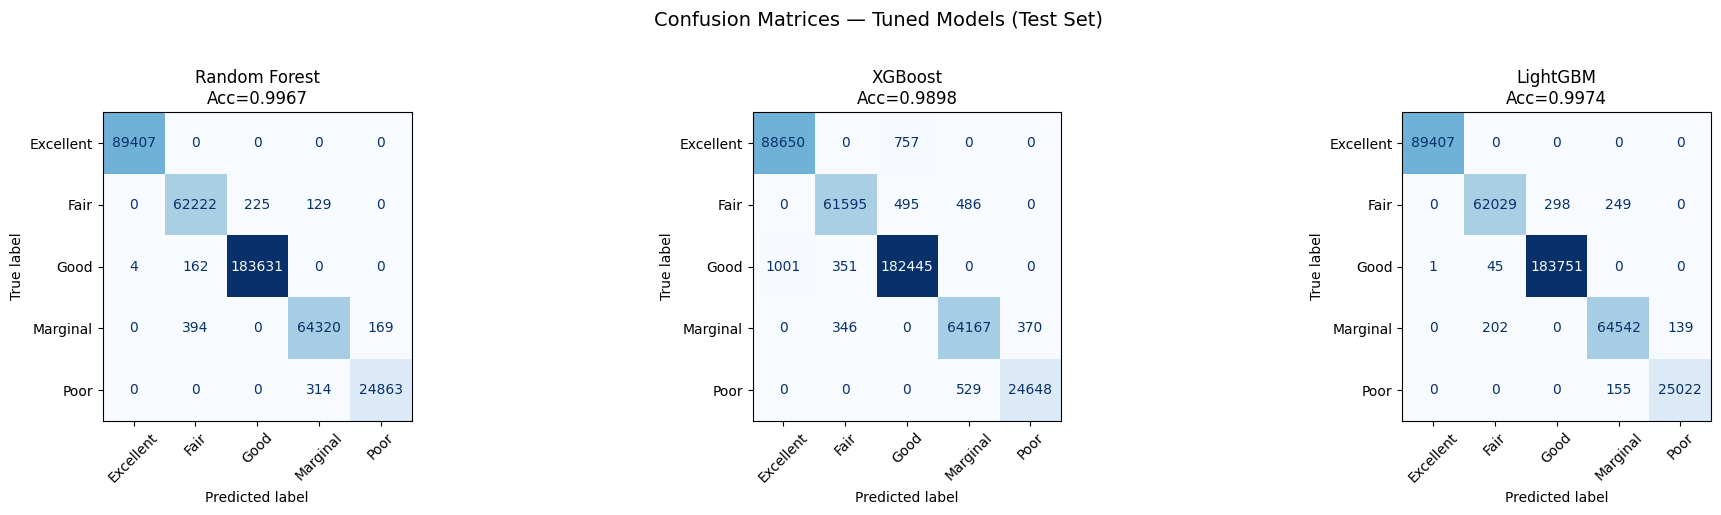

In [26]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
class_names = ['Excellent', 'Fair', 'Good', 'Marginal', 'Poor']

for ax, (name, (model, y_true, is_encoded)) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    y_true_labels = le.inverse_transform(y_true) if is_encoded else y_true
    y_pred_labels = le.inverse_transform(y_pred) if is_encoded else y_pred

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_true_labels, y_pred_labels):.4f}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Tuned Models (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('../results/confusion_matrices_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
results = []

models = {
    'Random Forest': (rf_clf_search.best_estimator_,  y_test,     False),
    'XGBoost':       (xgb_clf_search.best_estimator_, y_test_enc, True),
    'LightGBM':      (lgbm_clf_search.best_estimator_,y_test,     False),
}

for name, (model, y_true, is_encoded) in models.items():
    y_pred = model.predict(X_test_scaled)
    y_true_labels = le.inverse_transform(y_true) if is_encoded else y_true
    y_pred_labels = le.inverse_transform(y_pred) if is_encoded else y_pred

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_true_labels, y_pred_labels),
        'Precision': precision_score(y_true_labels, y_pred_labels, average='weighted'),
        'Recall':    recall_score(y_true_labels, y_pred_labels, average='weighted'),
        'F1':        f1_score(y_true_labels, y_pred_labels, average='weighted'),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))


/opt/anaconda3/envs/DS-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               Accuracy  Precision  Recall      F1
Model                                             
Random Forest    0.9967     0.9967  0.9967  0.9967
XGBoost          0.9898     0.9898  0.9898  0.9898
LightGBM         0.9974     0.9974  0.9974  0.9974


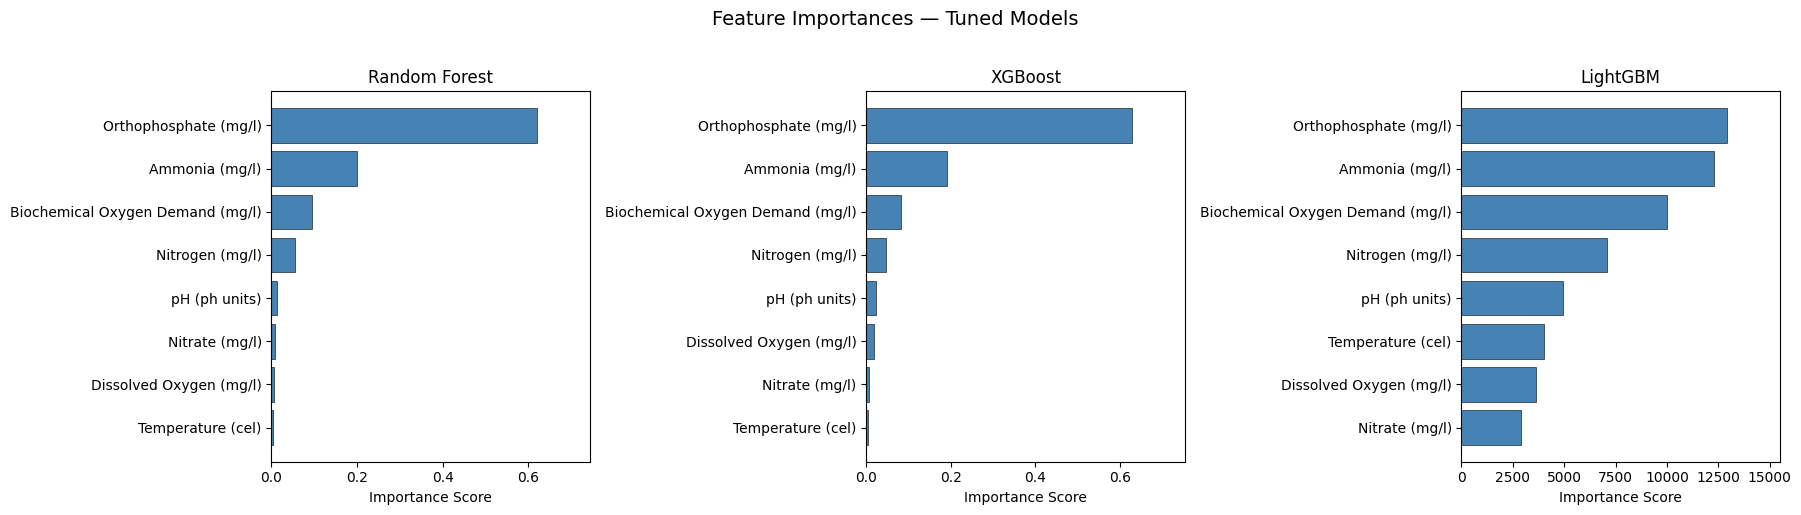

In [28]:
feature_names = X_train.columns.tolist()

importances = {
    'Random Forest': rf_clf_search.best_estimator_.feature_importances_,
    'XGBoost':       xgb_clf_search.best_estimator_.feature_importances_,
    'LightGBM':      lgbm_clf_search.best_estimator_.feature_importances_,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, imp) in zip(axes, importances.items()):
    # sort descending
    sorted_idx = np.argsort(imp)
    sorted_imp = imp[sorted_idx]
    sorted_features = [feature_names[i] for i in sorted_idx]

    bars = ax.barh(sorted_features, sorted_imp, color='steelblue', edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Importance Score')
    ax.set_title(name)
    ax.set_xlim(0, max(imp) * 1.2)

plt.suptitle('Feature Importances — Tuned Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
